In [1]:
import pandas as pd

In [2]:
dataset = pd.read_excel(
    r"C:\Users\sarth\Downloads\UP_FRAUD_DATASET.xlsx",
    index_col=0
)

In [3]:
import numpy as np

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X = dataset.iloc[:, :9].values      # First 9 columns
y = dataset.iloc[:, 9].values       # fraud_risk column
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

In [8]:
fraud=np.count_nonzero(y_train==1)
valid=np.count_nonzero(y_train==0)

In [9]:
print('Fraud cases in training data=',fraud)
print('Valid cases in training data=',valid)

Fraud cases in training data= 21
Valid cases in training data= 139


In [10]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [11]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [12]:
X_train[:5]

array([[-0.27633178,  1.57876318,  0.        , -1.14866621,  0.60051771,
         1.42628792,  0.36849102,  1.16519971,  0.41595233],
       [-1.29663376,  0.16757822,  0.        ,  0.64312509,  1.06503123,
        -1.4504916 , -0.96494937, -0.86992493,  1.6124755 ],
       [ 1.19743773,  1.0142892 ,  0.        , -1.66060658,  0.13600419,
         1.09435183, -1.28188954, -0.72455889, -0.08244689],
       [-1.52336753, -1.24360675,  0.        , -0.38075565,  0.35039504,
        -0.39936062,  0.83027714, -0.21577772,  1.20389998],
       [-1.29663376,  1.57876318,  0.        ,  0.38715491,  0.10027238,
         1.31564256, -1.14661161,  1.45593181,  1.15081351]])

In [13]:
X_test[:5]

array([[-1.29663376, -0.39689577,  0.        , -1.14866621,  0.15387009,
        -0.7866194 ,  1.07274456, -1.59675516, -1.44354975],
       [ 1.08407085,  0.16757822,  0.        , -0.63672584, -1.329     ,
        -1.4504916 ,  0.98076542,  0.14763739,  0.36476874],
       [ 0.6306033 , -0.39689577,  0.        ,  1.41103565,  1.40448342,
        -0.23339257, -1.32434813, -1.45138912,  0.5384745 ],
       [ 0.97070396,  1.57876318,  0.        ,  0.13118472,  1.70820379,
        -1.28452355, -1.67837982,  0.07495437,  1.41845941],
       [-0.72979933, -1.24360675,  0.        ,  0.13118472,  1.60100837,
         0.92838378, -1.42527965,  0.87446762,  0.49431992]])

In [14]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
LR_model=LogisticRegression(random_state=0)
LR_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,0
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
y_pred=LR_model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score

In [17]:
acc_lr=accuracy_score(y_test,y_pred)

In [18]:
print(acc_lr)

0.925


In [19]:
#K Nearest Neighbors (KNN) Classifier
from sklearn.neighbors import KNeighborsClassifier
KNN_model=KNeighborsClassifier(n_neighbors=5,metric='minkowski',p=2)
KNN_model.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [20]:
y_pred=KNN_model.predict(X_test)
acc_KNN=accuracy_score(y_test,y_pred)
print(acc_KNN)


0.925


In [21]:
#Support Vector Machines (SVM)
from sklearn.svm import SVC
SVM_model=SVC(kernel='linear',random_state=0)
SVM_model.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [22]:
y_pred=SVM_model.predict(X_test)
acc_SVM=accuracy_score(y_test,y_pred)
print(acc_SVM)

0.925


In [23]:
#Naive Bayes Classifier
from sklearn.naive_bayes import GaussianNB
NB_model=GaussianNB()
NB_model.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [24]:
y_pred=NB_model.predict(X_test)
acc_NB=accuracy_score(y_test,y_pred)
print(acc_NB)

0.95


In [25]:
#Decision Tree Clssifier
from sklearn.tree import DecisionTreeClassifier
DT_model=DecisionTreeClassifier(criterion='entropy',random_state=2)
DT_model.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [26]:
y_pred=DT_model.predict(X_test)
acc_DT=accuracy_score(y_test,y_pred)
print(acc_DT)

0.825


In [27]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
RF_model=RandomForestClassifier()
RF_model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
y_pred=RF_model.predict(X_test)
acc_RF=accuracy_score(y_test,y_pred)
print(acc_RF)

0.875


In [29]:
#Convolutional Neural Networks
import tensorflow as tf

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
CNN_model = Sequential()
CNN_model.add(Dense(64, activation='relu', input_dim=9))
CNN_model.add(Dense(32, activation='relu'))
CNN_model.add(Dense(1, activation='sigmoid'))
CNN_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [44]:
CNN_model.fit(X_train, y_train, batch_size=32, epochs=100)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0127
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0125
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.0123
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0120 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0119
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0117 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0116
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0114
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0111
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0110
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0108
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - 

In [45]:
loss,acc_cnn=CNN_model.evaluate(X_train,y_train,verbose=0)
print(acc_cnn)

1.0


In [46]:
y_pred=CNN_model.predict(X_test)
y_pred[y_pred<=0.5]=0
y_pred[y_pred>=0.5]=1

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


In [56]:
#Accuracy Comparisons
scores=[acc_lr*100,acc_KNN*100,acc_SVM*100,acc_NB*100,acc_DT*100,acc_RF*100,acc_cnn*100]
names=["Logistic Regression","K-Nearest Neighbors","Support Vector Machine","Naive Bayes","Decision Tree","Random Forest","Convolutional Neural Network"]
df=pd.DataFrame()
df['Algorithm Name']=names
df['Accuracy Score (%)']=scores
df = df.sort_values('Accuracy Score (%)', ascending=False)
df

,Algorithm Name,Accuracy Score (%)
6,Convolutional Neural Network,100.0
3,Naive Bayes,95.0
0,Logistic Regression,92.5
1,K-Nearest Neighbors,92.5
2,Support Vector Machine,92.5
5,Random Forest,87.5
4,Decision Tree,82.5


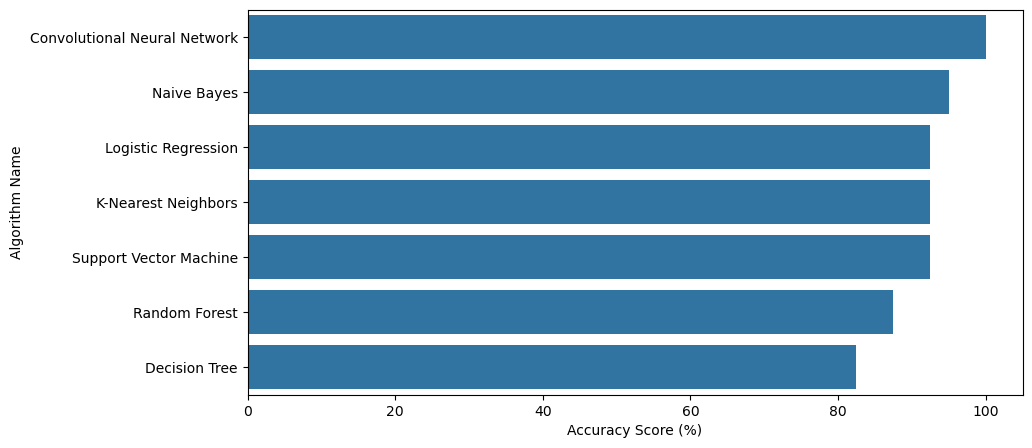

In [59]:

import matplotlib.pyplot as plt
import seaborn as sns
fig=plt.subplots(figsize=(10,5))
ax=sns.barplot(x="Accuracy Score (%)",y="Algorithm Name",data=df)
